# ReAct实现
## ReAct原理：
    - Reasoning: 思考，LLM根据当前对话思考如何行动
    - Action: 行动，根据思考结构，决定是否要调用工具
    - Observation: 观察，调用工具后将`ToolMessage`发给LLM，再次进入Reasoning
    - Loop: ReAct本质就是和大模型的一个Loop循环, 直至给出Final Answer

## 实现方式

In [22]:
from typing import TypedDict
from random import randint

from IPython.core.display import Image, display_png
from fastmcp.utilities.docstring_parsing import parse_docstring
from langchain_core.messages import HumanMessage, ToolMessage
from langchain_core.messages.tool import tool_call
from langchain_core.tools import tool
from langgraph.constants import START, END
from langgraph.graph import MessagesState, StateGraph

from common import init_simple_dashscope_model

model = init_simple_dashscope_model(extra_body={
    "enable_thinking": False
})

@tool(description="查询指定城市天气", parse_docstring=True)
def get_weather(city: str):
    """
    查询指定城市天气

    Args:
        city: 城市

    Returns:
        天气情况

    """
    return f'{city}天气阳光明媚!'

@tool(description="获取指定主题写新闻")
def get_news(topic: str):
    """
    获取指定主题写新闻

    Args:
        topic: 主题

    Returns:
        新闻内容

    """
    return f'最新{topic}消息报导：马斯克和Wgx在深圳会面，留下了历史性的一幕'

model_with_tools = model.bind_tools([get_weather, get_news])

tool_map = {
    "get_weather": get_weather,
    "get_news": get_news
}

class OverAllState(MessagesState):
    pass


class OutputState(MessagesState):
    final_answer: str

def tool_invoke_node(state: OverAllState) -> OverAllState:
    ai_message = state['messages'][-1]
    fail_rate = 6

    tool_message = None

    for tool_item in ai_message.tool_calls:
            if tool_item['name'] in tool_map:
                if randint(0, 9) < fail_rate:
                    tool_message = ToolMessage(
                        content=f"{tool_item['name']}工具网络异常调用失败,请重试!",
                        tool_call_id=tool_item['id']
                    )
                else:
                    tool_result = tool_map[tool_item['name']].invoke(tool_item['args'])
                    tool_message = ToolMessage(
                        content=tool_result,
                        tool_call_id=tool_item['id']
                    )
            else:
                tool_message = ToolMessage(
                        content=f"{tool_item['name']}工具名称错误，调用失败，请重试!",
                        tool_call_id=tool_item['id']
                    )

    return {
        "messages": [tool_message]
    }

def output_node(state: OverAllState) -> OutputState:
    return {
        "final_answer": state.get('messages')[-1].content,
        "messages": state.get('messages')
    }

### 静态路由 - add_conditional_edges

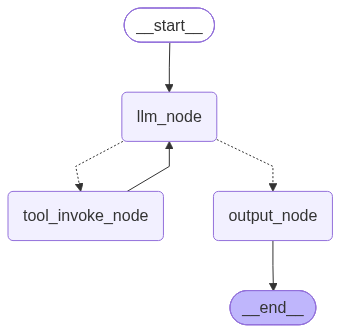

================================================== weather_res ==================================================
很抱歉，经过多次尝试，查询北京天气的工具持续出现网络异常，目前无法获取实时的天气数据。

建议您通过其他渠道（如手机天气应用、气象网站等）查询北京的最新天气情况。
================================================== weather pretty res ==================================================
================================ System Message ================================

如果工具调用失败！要调用直至成功!
================================ Human Message =================================

北京天气如何？
================================== Ai Message ==================================
Tool Calls:
  get_weather (call_0d394ac0b5db48308284c70f)
 Call ID: call_0d394ac0b5db48308284c70f
  Args:
    city: 北京
================================= Tool Message =================================

get_weather工具网络异常调用失败,请重试!
================================== Ai Message ==================================
Tool Calls:
  get_weather (call_f0ff4550a64a4ad9b28e01de)
 Call ID: call_f0ff4550a64a4ad9b28e01de
  Arg

In [23]:
from langchain_core.messages import SystemMessage
from typing import Literal


def router(state: OverAllState) -> Literal["tool_invoke_node", "output_node"]:
    messages = state['messages']
    ai_message = messages[-1]
    if ai_message.tool_calls:
        return 'tool_invoke_node'
    else:
        return 'output_node'


def llm_node(state: OverAllState) -> OverAllState:
    resp = model_with_tools.invoke(
        state.get('messages')
    )
    return {
        "messages": [resp]
    }

state_graph = StateGraph(state_schema=OverAllState, output_schema=OutputState)
state_graph.add_node('tool_invoke_node', tool_invoke_node)
state_graph.add_node('output_node', output_node)
state_graph.add_node('llm_node', llm_node)

state_graph.add_edge(START, 'llm_node')
state_graph.add_conditional_edges('llm_node', router, path_map=['tool_invoke_node', 'output_node'])
state_graph.add_edge('tool_invoke_node', 'llm_node')
state_graph.add_edge('output_node', END)
graph = state_graph.compile()
png = Image(graph.get_graph().draw_mermaid_png())
display_png(png)

resp = graph.invoke(
    {
        "messages": [
            SystemMessage(content="如果工具调用失败！要调用直至成功!"),
            HumanMessage(content="北京天气如何？")
        ]
    }
)
print('=' * 50, 'weather_res', '=' * 50)
print(resp['final_answer'])
print('=' * 50, 'weather pretty res', '=' * 50)
for message in resp['messages']:
    message.pretty_print()


resp1 = graph.invoke(
    {
        "messages": [
            SystemMessage(content="如果工具调用失败！要调用直至成功!"),
            HumanMessage(content='今天科技有什么新闻？')
        ]
    }
)
print('=' * 50, 'news_res', '=' * 50)
print(resp1['final_answer'])
print('=' * 50, 'news pretty res', '=' * 50)
for message in resp1['messages']:
    message.pretty_print()


### 动态路由 - Command

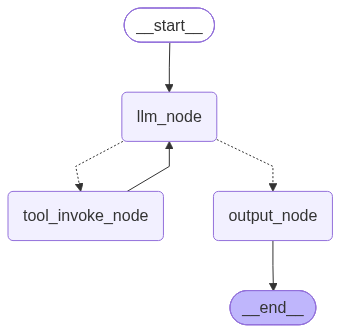

================================================== weather_res ==================================================
根据查询结果，北京目前天气阳光明媚！
================================================== weather pretty res ==================================================
================================ System Message ================================

如果工具调用失败！要调用直至成功!
================================ Human Message =================================

北京天气如何？
================================== Ai Message ==================================

我来查询北京的天气情况。
Tool Calls:
  get_weather (call_3d130b5a157648c8b2d4b027)
 Call ID: call_3d130b5a157648c8b2d4b027
  Args:
    city: 北京
================================= Tool Message =================================

get_weather工具网络异常调用失败,请重试!
================================== Ai Message ==================================

调用失败了，我再试一次。
Tool Calls:
  get_weather (call_0710ab55739145259ef72444)
 Call ID: call_0710ab55739145259ef72444
  Args:
    city: 北京
===================

In [27]:
from langgraph.types import Command
from langchain_core.messages import SystemMessage
from typing import Literal

def llm_node(state: OverAllState) -> Command[Literal['tool_invoke_node', 'output_node']]:
    resp = model_with_tools.invoke(
        state.get('messages')
    )
    if resp.tool_calls:
        return Command(
            goto='tool_invoke_node',
            update={
                "messages": [resp]
            }
        )
    else:
        return Command(
            goto='output_node',
            update={
                "messages": [resp]
            }
        )

state_graph = StateGraph(state_schema=OverAllState, output_schema=OutputState)
state_graph.add_node('tool_invoke_node', tool_invoke_node)
state_graph.add_node('output_node', output_node)
state_graph.add_node('llm_node', llm_node)

state_graph.add_edge(START, 'llm_node')
state_graph.add_edge('tool_invoke_node', 'llm_node')
state_graph.add_edge('output_node', END)
graph = state_graph.compile()
png = Image(graph.get_graph().draw_mermaid_png())
display_png(png)

resp = graph.invoke(
    {
        "messages": [
            SystemMessage(content="如果工具调用失败！要调用直至成功!"),
            HumanMessage(content="北京天气如何？")
        ]
    }
)
print('=' * 50, 'weather_res', '=' * 50)
print(resp['final_answer'])
print('=' * 50, 'weather pretty res', '=' * 50)
for message in resp['messages']:
    message.pretty_print()


resp1 = graph.invoke(
    {
        "messages": [
            SystemMessage(content="如果工具调用失败！要调用直至成功!"),
            HumanMessage(content='今天科技有什么新闻？')
        ]
    }
)
print('=' * 50, 'news_res', '=' * 50)
print(resp1['final_answer'])
print('=' * 50, 'news pretty res', '=' * 50)
for message in resp1['messages']:
    message.pretty_print()


## 循环最大次数
1. 运行时配置config的recursion_limit
    ```python
        graph.invoke(input, config={"recursion_limit": 10})
    ```
   lang_graph有默认的recursion_limit,但有多个默认值，需要区分，建议在运行时显示指定，防止由于运行方式不同导致使用意料之外的默认值，出现异常：
    - langchain_core.runnables.config，默认25,RunnableConfig 中定义的默认值，LangChain Agent 运行时生效
    - langgraph._internal._config，默认10000，LangGraph 本地图运行时内部配置中的默认值，自定义 LangGraph 图结构时生效
    - langgraph_api.utils.config，默认10011，LangGraph API / 服务侧相关配置中的默认值
2. 在状态中定义`RemainingSteps`的状态字段，在节点中可以获取该字段和`config`中的`recursion_limit`做比较，决定是否退出
3. 如果循环次数超过`recursion_limit`,会抛出`GraphRecursionError`异常,我们可以捕获该异常作为兜底机制

### 主动退出循环和被动退出循环对比
- 主动退出可以在退出时保存checkpoint,利于恢复
- 主动退出可以通过返回部分结果，改善用户体验
- 被动退出可以作为兜底机制

In [ ]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langgraph.managed import RemainingSteps
from langchain_core.runnables.config import RunnableConfig
from loguru import logger



class OverAllState(TypedDict):
    remaining_steps: RemainingSteps

def loop_node(state: OverAllState, config: RunnableConfig) -> OverAllState:
    cur_step = config["metadata"]["langgraph_step"]
    remaining_steps = state["remaining_steps"]
    logger.info("loop_node, cur_step: {}, remaining_step: {}", cur_step, remaining_steps)

def router(state: OverAllState) -> Literal["loop_node", END]:
    remaining_steps = state["remaining_steps"]
    if remaining_steps < 3:
        logger.info("当前可用超步：{}，已不足2步，终止运行图", remaining_steps)
        return END
    return "loop_node"

builder = StateGraph(state_schema=OverAllState)
builder.add_node("loop_node", loop_node)
builder.add_edge(START, "loop_node")
builder.add_conditional_edges("loop_node", router)

graph = builder.compile()
graph.invoke({}, config={"recursion_limit": 10})

from IPython.display import display
display(graph)